# Boston Housing 주택 가격 예측

## 실습 목표
본 실습에서는 Boston Housing 데이터셋을 이용하여  
다층 퍼셉트론(MLP) 기반 **회귀 모델**을 구현하고, 학습 결과를 분석한다.

## 실습 내용
- Boston Housing 데이터셋 불러오기
- 데이터 전처리 및 학습/검증 데이터 분리
- 표준화(Standardization) 적용
- 회귀용 MLP 모델 구성
- 모델 학습 및 성능 평가
- 예측 결과 확인
- K-Fold 교차검증을 통한 성능 점검

---

#### 1] 라이브러리 import

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from typing import Any
from tensorflow.keras.datasets.boston_housing import load_data
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

#### 2] 상수 정의

In [2]:
RANDOM_STATE = 777
NUM_FEATURES = 13
EPOCHS = 300
BATCH_SIZE = 32
VALIDATION_RATIO = 0.33
K_FOLDS = 3

## 데이터셋 소개

- Boston Housing 데이터셋은 보스턴 지역 주택 정보를 바탕으로 주택 가격을 예측하는 대표적인 **회귀 데이터셋**이다.
- 입력값은 총 `13개`의 feature로 구성된다.
- 출력값은 주택 가격처럼 **연속적인 수치**이므로, 이 문제는 분류가 아니라 **회귀(regression)** 문제이다.

#### 3] 데이터 준비 함수

##### 데이터 전처리

모델 학습을 위해 다음과 같은 전처리를 수행한다.

1. 데이터셋을 불러온다.
2. 학습 데이터를 학습용(train)과 검증용(validation)으로 분리한다.
3. 훈련 데이터 기준으로 평균(mean)과 표준편차(std)를 계산한다.
4. 같은 기준으로 train / validation / test 데이터에 **표준화**를 적용한다.

표준화는 feature마다 값의 크기 차이가 큰 경우 학습을 더 안정적으로 만들기 위해 사용한다.

$$
z = \frac{x - mean}{std}
$$

In [3]:
def load_and_prepare_data(
    validation_ratio: float = VALIDATION_RATIO,
    random_state: int = RANDOM_STATE
) -> tuple:
    (x_train, y_train), (x_test, y_test) = load_data(
        path="boston_housing.npz",
        test_split=0.2,
        seed=random_state
    )

    x_train, x_val, y_train, y_val = train_test_split(
        x_train,
        y_train,
        test_size=validation_ratio,
        random_state=random_state
    )

    mean = x_train.mean(axis=0)
    std = x_train.std(axis=0)
    std[std == 0] = 1

    x_train = (x_train - mean) / std
    x_val = (x_val - mean) / std
    x_test = (x_test - mean) / std

    return x_train, x_val, y_train, y_val, x_test, y_test, mean, std

#### 4] 샘플 데이터 확인 함수

##### 샘플 데이터 확인

회귀 문제에서는 이미지 대신 feature 벡터와 target 값을 확인하는 방식이 더 자연스럽다.

- 입력 feature 일부를 확인하여 데이터가 정상적으로 로드되었는지 점검한다.
- 대응되는 실제 target 값도 함께 출력한다.

In [4]:
def show_sample_rows(
    features: np.ndarray,
    targets: np.ndarray,
    sample_size: int = 3,
    random_state: int = RANDOM_STATE
) -> None:
    rng = np.random.default_rng(random_state)
    random_idx = rng.choice(len(features), size=sample_size, replace=False)

    for idx in random_idx:
        print(f"[Index: {idx}]")
        print("Features:", np.round(features[idx], 3))
        print("Target  :", round(float(targets[idx]), 3))
        print("-" * 60)

#### 5] 모델 생성 함수

##### 모델 구성

- 입력 데이터는 `13차원` feature 벡터이다.
- 은닉층은 `[64, 32]` 구조로 구성한다.
- 활성화 함수는 `relu`를 사용한다.
- 출력층은 `Dense(1)`로 구성한다.

회귀 문제이므로 마지막 층은 보통 활성화 함수를 두지 않고,  
연속적인 값을 그대로 출력하도록 한다.

In [5]:
def build_dense_regression_model(hidden_units: list[int]) -> Sequential:
    model = Sequential([
        Input(shape=(NUM_FEATURES,)),
        *[Dense(units, activation="relu") for units in hidden_units],
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

#### 6] 학습 함수

##### 모델 학습

모델은 다음과 같은 학습 조건에서 학습을 수행한다.

- Optimizer: Adam
- Loss Function: MSE (Mean Squared Error)
- Metric: MAE (Mean Absolute Error)
- Epochs: 300
- Batch Size: 32

여기서 중요한 점은:

- `loss='mse'`는 모델이 실제로 줄여나가는 학습 목표
- `metrics=['mae']`는 사람이 결과를 보기 쉽게 확인하는 보조 지표

즉, **학습 기준은 MSE**, **해석용 지표는 MAE**라고 이해하면 된다.

In [6]:
def train_model(
    model: Sequential,
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
    epochs: int = EPOCHS,
    batch_size: int = BATCH_SIZE
):
    return model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, y_val),
        verbose=0
    )

#### 7] 학습 결과 시각화 함수

##### 학습 결과 시각화

학습 과정에서 기록된 MSE와 MAE를 그래프로 시각화한다.

이를 통해 다음을 확인할 수 있다.

- 학습이 정상적으로 진행되는지
- train / validation 간 차이가 큰지
- 과적합이 발생하는지

In [7]:
def plot_history(history: Any, title_prefix: str = "Boston Housing Model") -> None:
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    sns.set_theme(style="whitegrid", context="notebook")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.lineplot(x=list(epochs), y=hist["loss"], ax=axes[0], label="train_loss")
    sns.lineplot(x=list(epochs), y=hist["val_loss"], ax=axes[0], label="val_loss")
    axes[0].set_title(f"{title_prefix} Loss (MSE)")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("MSE")

    sns.lineplot(x=list(epochs), y=hist["mae"], ax=axes[1], label="train_mae")
    sns.lineplot(x=list(epochs), y=hist["val_mae"], ax=axes[1], label="val_mae")
    axes[1].set_title(f"{title_prefix} MAE")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("MAE")

    plt.tight_layout()
    plt.show()

#### 8] 예측 결과 확인 함수

##### 예측 결과 확인

테스트 데이터 일부 샘플에 대해:

- 실제 주택 가격
- 예측한 주택 가격
- 오차의 크기

를 확인한다.  
회귀 문제에서는 분류처럼 확률 대신 **예측값과 실제값의 차이**를 보는 것이 핵심이다.

In [8]:
def show_prediction_samples(
    x_data: np.ndarray,
    y_true: np.ndarray,
    predictions: np.ndarray,
    sample_size: int = 5,
    random_state: int = RANDOM_STATE
) -> None:
    rng = np.random.default_rng(random_state)
    random_idx = rng.choice(len(x_data), size=sample_size, replace=False)

    for idx in random_idx:
        true_value = float(y_true[idx])
        pred_value = float(predictions[idx][0])
        abs_error = abs(true_value - pred_value)

        print(f"[Index: {idx}]")
        print(f"True Value      : {true_value:.3f}")
        print(f"Predicted Value : {pred_value:.3f}")
        print(f"Absolute Error  : {abs_error:.3f}")
        print("-" * 50)

In [9]:
def plot_true_vs_pred(y_true: np.ndarray, predictions: np.ndarray) -> None:
    pred_values = predictions.reshape(-1)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, pred_values, alpha=0.7)
    plt.xlabel("True Value")
    plt.ylabel("Predicted Value")
    plt.title("True vs Predicted")
    plt.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        linestyle="--"
    )
    plt.show()

#### 9] K-Fold 교차검증 함수

##### K-Fold 교차검증

훈련 데이터를 여러 조각으로 나누어 번갈아 검증하면,  
한 번의 train/validation 분할 결과에만 의존하지 않고 성능을 더 안정적으로 점검할 수 있다.

여기서는 각 fold마다:

1. 학습 데이터를 다시 나눈다.
2. 훈련 fold 기준으로 표준화한다.
3. 모델을 새로 생성해 학습한다.
4. 해당 validation fold의 MAE를 기록한다.

In [10]:
def run_kfold_validation(
    x_data: np.ndarray,
    y_data: np.ndarray,
    k_folds: int = K_FOLDS,
    epochs: int = EPOCHS,
    batch_size: int = BATCH_SIZE,
    random_state: int = RANDOM_STATE
) -> list[float]:
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=random_state)
    fold_mae_list = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(x_data), start=1):
        x_train_fold, x_val_fold = x_data[train_idx], x_data[val_idx]
        y_train_fold, y_val_fold = y_data[train_idx], y_data[val_idx]

        mean = x_train_fold.mean(axis=0)
        std = x_train_fold.std(axis=0)
        std[std == 0] = 1

        x_train_fold = (x_train_fold - mean) / std
        x_val_fold = (x_val_fold - mean) / std

        model = build_dense_regression_model([64, 32])
        model.fit(
            x_train_fold,
            y_train_fold,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(x_val_fold, y_val_fold),
            verbose=0
        )

        _, val_mae = model.evaluate(x_val_fold, y_val_fold, verbose=0)
        fold_mae_list.append(val_mae)

        print(f"Fold {fold} Validation MAE: {val_mae:.4f}")

    return fold_mae_list

---

#### 데이터 로드 및 확인

In [11]:
x_train, x_val, y_train, y_val, x_test, y_test, mean, std = load_and_prepare_data()

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val  :", x_val.shape)
print("y_val  :", y_val.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

x_train: (270, 13)
y_train: (270,)
x_val  : (134, 13)
y_val  : (134,)
x_test : (102, 13)
y_test : (102,)


#### 샘플 데이터 보기

In [12]:
show_sample_rows(
    features=x_train,
    targets=y_train,
)

[Index: 95]
Features: [-0.402  1.818 -0.914 -0.283 -1.316 -0.111 -1.415  1.725 -0.442 -0.727
 -0.84   0.428 -0.798]
Target  : 23.2
------------------------------------------------------------
[Index: 242]
Features: [-0.365 -0.491 -0.787 -0.283 -0.485  1.285  0.355 -0.256 -0.219 -0.646
 -0.479  0.136 -0.908]
Target  : 31.6
------------------------------------------------------------
[Index: 164]
Features: [-0.398  1.269 -0.756 -0.283 -0.964  0.288 -1.386  0.19  -0.665 -0.955
 -0.388  0.428 -0.791]
Target  : 29.1
------------------------------------------------------------


#### 모델 생성

##### 모델 정보

- 본 실습에서는 은닉층을 `[64, 32]` 형태로 구성한 기본적인 MLP 회귀 모델을 사용한다.
- 출력값이 연속형 수치이므로 마지막 층은 `Dense(1)`이다.
- `loss='mse'`, `metrics=['mae']` 조합은 회귀 문제에서 매우 자주 사용된다.

In [13]:
model = build_dense_regression_model([64, 32])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

#### 모델 학습

In [14]:
history = train_model(model, x_train, y_train, x_val, y_val)

#### 결과 시각화

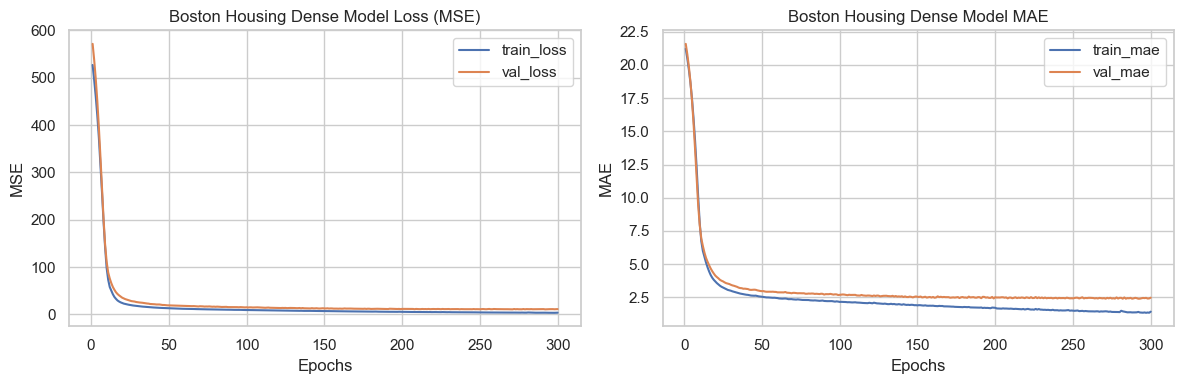

In [15]:
plot_history(history, title_prefix="Boston Housing Dense Model")

#### 테스트 데이터 평가

In [16]:
test_loss, test_mae = model.evaluate(x_test, y_test, verbose=0)

print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE       : {test_mae:.4f}")

Test Loss (MSE): 9.7746
Test MAE       : 2.3208


#### 예측 수행 및 결과 확인

In [17]:
predictions = model.predict(x_test, verbose=0)
print("예측 결과 shape:", predictions.shape)

예측 결과 shape: (102, 1)


In [18]:
show_prediction_samples(
    x_data=x_test,
    y_true=y_test,
    predictions=predictions,
    sample_size=5
)

[Index: 9]
True Value      : 24.400
Predicted Value : 25.506
Absolute Error  : 1.106
--------------------------------------------------
[Index: 88]
True Value      : 45.400
Predicted Value : 44.567
Absolute Error  : 0.833
--------------------------------------------------
[Index: 35]
True Value      : 33.200
Predicted Value : 32.626
Absolute Error  : 0.574
--------------------------------------------------
[Index: 60]
True Value      : 23.200
Predicted Value : 22.128
Absolute Error  : 1.072
--------------------------------------------------
[Index: 38]
True Value      : 31.500
Predicted Value : 29.501
Absolute Error  : 1.999
--------------------------------------------------


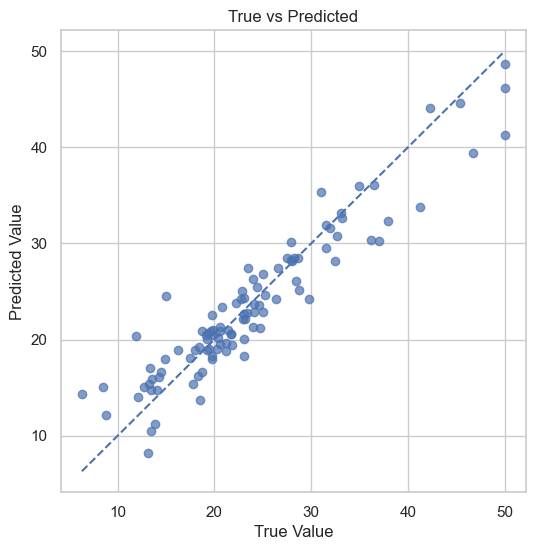

In [19]:
plot_true_vs_pred(y_test, predictions)

#### K-Fold 교차검증

In [20]:
(x_train_full, y_train_full), _ = load_data(
    path="boston_housing.npz",
    test_split=0.2,
    seed=RANDOM_STATE
)

kfold_mae_list = run_kfold_validation(
    x_data=x_train_full,
    y_data=y_train_full,
    k_folds=K_FOLDS
)

print("각 fold의 validation MAE:", kfold_mae_list)
print("평균 validation MAE    :", np.mean(kfold_mae_list))

Fold 1 Validation MAE: 2.4444
Fold 2 Validation MAE: 2.7304
Fold 3 Validation MAE: 2.4254
각 fold의 validation MAE: [2.4444239139556885, 2.730386257171631, 2.4254066944122314]
평균 validation MAE    : 2.533405621846517


## 모델 학습 결과 분석

이번 실습에서는 Boston Housing 데이터셋을 이용하여 다층 퍼셉트론(MLP) 기반 회귀 모델을 학습하고, 그 결과를 손실(Loss), MAE, 예측값 비교, K-Fold 교차검증을 통해 분석하였다.

### 1. 전체적인 학습 경향
학습 결과, train loss와 validation loss가 전반적으로 감소하는 모습을 보이면 모델이 데이터를 정상적으로 학습하고 있다고 볼 수 있다.  
다만 validation loss가 중간부터 다시 상승한다면 과적합 가능성을 의심할 수 있다.

### 2. 모델 성능
테스트 데이터 평가 결과 MSE와 MAE를 통해 모델의 오차 수준을 확인할 수 있다.  
특히 MAE는 평균적으로 예측이 실제값에서 얼마나 벗어났는지 직관적으로 보여준다.

### 3. 예측 결과 해석
일부 샘플의 실제값과 예측값을 비교하면, 모델이 어느 정도 수준으로 주택 가격을 근사하고 있는지 직접 확인할 수 있다.  
또한 True vs Predicted 산점도를 통해 예측값이 이상적인 대각선 부근에 모이는지도 볼 수 있다.

### 4. K-Fold 교차검증
K-Fold를 통해 여러 번 검증한 MAE의 평균을 보면,  
단일 train/validation 분할보다 더 안정적으로 모델 성능을 해석할 수 있다.

### 5. 결론
이번 실습을 통해 기본적인 MLP 구조만으로도 회귀 문제를 해결할 수 있음을 확인하였다.  
이후에는 은닉층 구조 변경, 조기 종료(Early Stopping), 정규화 기법 등을 적용하여 성능을 비교해볼 수 있다.

## 표준화(Standardization)가 왜 필요한가?

Boston Housing 데이터셋의 입력값은 총 13개의 feature로 구성되어 있다.  
그런데 각 feature는 **값의 범위와 단위가 서로 다를 수 있다**.

예를 들어 어떤 feature는 값이 `0 ~ 1` 사이일 수도 있고,  
어떤 feature는 수십 또는 수백 단위일 수도 있다.

이처럼 feature마다 스케일이 크게 다르면,  
모델은 특정 feature에 지나치게 민감하게 반응하거나  
학습이 불안정해질 수 있다.

그래서 각 feature를 비슷한 기준으로 맞춰주는 전처리가 필요한데,  
그 대표적인 방법이 **표준화(Standardization)** 이다.

---

### 1. 표준화의 개념

표준화는 각 feature에 대해 평균을 0 근처로 맞추고,  
표준편차를 1 근처로 맞추는 변환이다.

공식은 다음과 같다.

$$
z = \frac{x - \mu}{\sigma}
$$

여기서:

- $x$: 원래 값
- $\mu$: 평균(mean)
- $\sigma$: 표준편차(standard deviation)
- $z$: 표준화된 값

즉,  
각 feature에서 평균을 빼고 표준편차로 나누어  
값의 중심과 크기를 맞춰주는 과정이다.

---

### 2. 왜 표준화가 필요한가?

신경망은 입력값을 바탕으로 가중치를 학습한다.  
그런데 어떤 feature는 값이 매우 크고,  
어떤 feature는 값이 매우 작다면 학습 과정에서 균형이 깨질 수 있다.

예를 들어:

- feature A: 값 범위가 `0 ~ 1`
- feature B: 값 범위가 `0 ~ 1000`

이 경우 모델은 feature B의 영향을 더 크게 받기 쉽다.  
즉, 값의 크기 차이 때문에  
**실제로 더 중요한 feature가 아니라 단지 숫자가 큰 feature가 더 크게 작용할 수 있다.**

표준화를 하면 각 feature가 비슷한 기준 위에서 표현되므로,  
모델이 더 안정적으로 학습할 수 있다.

---

### 3. Boston Housing에서 표준화가 중요한 이유

Boston Housing 데이터셋의 feature들은 서로 성격이 다르다.  
어떤 값은 작은 범위를 가지지만,  
어떤 값은 훨씬 큰 숫자 범위를 가질 수 있다.

이 상태 그대로 학습하면:

- 경사하강법이 비효율적으로 동작할 수 있고
- 학습 속도가 느려질 수 있으며
- 특정 feature에 학습이 치우칠 수 있다

따라서 회귀 모델을 학습하기 전에  
각 feature를 표준화해주는 것이 일반적이다.

---

### 4. 표준화 예시

어떤 feature 값이 다음과 같다고 가정하자.

- 원본 데이터: `[10, 12, 14]`

이 데이터의 평균은:

$$
\mu = \frac{10 + 12 + 14}{3} = 12
$$

표준편차는 단순 예시로 `2`라고 하자.

그러면 표준화 결과는 다음과 같다.

#### 첫 번째 값

$$
z = \frac{10 - 12}{2} = -1
$$

#### 두 번째 값

$$
z = \frac{12 - 12}{2} = 0
$$

#### 세 번째 값

$$
z = \frac{14 - 12}{2} = 1
$$

즉, 원래 `[10, 12, 14]`였던 값이  
표준화 후에는 `[-1, 0, 1]`처럼 바뀐다.

이렇게 하면 값의 중심이 평균 0 근처로 이동하고,  
스케일도 일정하게 맞춰진다.

---

### 5. 표준화는 train / validation / test에 어떻게 적용해야 할까?

이 부분은 매우 중요하다.

표준화를 할 때 평균과 표준편차는  
**반드시 훈련 데이터(train data) 기준으로 계산해야 한다.**

즉:

1. train 데이터에서 mean과 std를 구한다.
2. 그 mean과 std를 이용해 train 데이터를 변환한다.
3. 같은 mean과 std를 이용해 validation 데이터와 test 데이터도 변환한다.

수식으로 표현하면:

$$
x_{train}^{\prime} = \frac{x_{train} - \mu_{train}}{\sigma_{train}}
$$

$$
x_{val}^{\prime} = \frac{x_{val} - \mu_{train}}{\sigma_{train}}
$$

$$
x_{test}^{\prime} = \frac{x_{test} - \mu_{train}}{\sigma_{train}}
$$

---

### 6. 왜 test 데이터의 평균과 표준편차를 따로 구하면 안 될까?

만약 test 데이터에서 따로 평균과 표준편차를 구해버리면,  
모델이 학습 과정에서 보지 말아야 할 정보까지 간접적으로 활용하게 된다.

이것을 보통 **데이터 누수(data leakage)** 라고 한다.

모델은 훈련 데이터만 보고 학습해야 하므로,  
전처리 기준도 반드시 훈련 데이터에서만 만들어야 한다.

즉:

- 올바른 방법: train 기준으로 train / val / test 모두 변환
- 잘못된 방법: train, val, test 각각 자기 평균과 표준편차로 따로 변환

---

### 7. 코드에서의 표준화 과정

Boston Housing 예제에서는 보통 다음과 같이 작성한다.

    mean = x_train.mean(axis=0)
    std = x_train.std(axis=0)

    x_train = (x_train - mean) / std
    x_val = (x_val - mean) / std
    x_test = (x_test - mean) / std

여기서 `axis=0`은  
각 feature 열(column)별로 평균과 표준편차를 구하겠다는 뜻이다.

즉, 13개의 feature 각각에 대해  
별도의 평균과 표준편차를 계산해서 표준화를 적용하는 것이다.

---

### 8. 표준화를 하면 어떤 장점이 있을까?

표준화를 하면 다음과 같은 장점이 있다.

#### 1) 학습이 더 안정적이다
입력값의 크기가 비슷해지므로  
모델이 특정 feature에만 과도하게 끌려가지 않는다.

#### 2) 경사하강법이 더 효율적으로 동작한다
값의 스케일이 너무 제각각이면  
최적화 과정이 비효율적일 수 있는데,  
표준화는 이를 완화해준다.

#### 3) 학습 속도가 좋아질 수 있다
입력값 범위가 정리되면  
가중치 업데이트가 더 자연스럽게 이루어질 수 있다.

#### 4) feature 간 비교가 쉬워진다
표준화된 값은  
각 feature가 평균에서 얼마나 떨어져 있는지 상대적으로 보여준다.

---

### 9. 표준화와 정규화는 같은가?

헷갈리기 쉬운 부분인데, 완전히 같은 것은 아니다.

#### 표준화(Standardization)
평균을 0, 표준편차를 1 근처로 맞추는 방법이다.

$$
z = \frac{x - \mu}{\sigma}
$$

#### 정규화(Normalization)
보통 값을 특정 범위, 예를 들어 `0 ~ 1` 사이로 맞추는 방법을 말한다.

예를 들어 Min-Max Scaling은 다음과 같다.

$$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

MNIST에서는 픽셀값을 `255`로 나누어 `0 ~ 1` 범위로 맞췄는데,  
그것은 보통 **정규화**에 가깝다.

반면 Boston Housing에서는 각 feature의 분포 차이를 줄이는 것이 중요하므로  
**표준화**를 자주 사용한다.

---

### 10. Boston Housing 문제에서의 해석

Boston Housing 데이터는 이미지처럼 모든 입력값이 같은 범위를 가지는 데이터가 아니다.  
각 feature의 의미와 범위가 서로 다르기 때문에,  
입력 전에 표준화를 적용하는 것이 매우 중요하다.

표준화를 하지 않으면:

- 학습이 느리거나 불안정할 수 있고
- 특정 feature가 과도하게 반영될 수 있으며
- 성능이 기대보다 낮아질 수 있다

반면 표준화를 적용하면  
모델이 각 feature를 보다 균형 있게 받아들이면서  
학습을 진행할 수 있다.

---

### 11. 결론

표준화(Standardization)는  
각 feature의 평균을 0 근처, 표준편차를 1 근처로 맞추는 전처리 방법이다.

공식은 다음과 같다.

$$
z = \frac{x - \mu}{\sigma}
$$

Boston Housing처럼 feature마다 값의 범위와 단위가 다른 회귀 문제에서는  
표준화가 특히 중요하다.

또한 표준화는 반드시 **훈련 데이터 기준으로만** 수행해야 하며,  
같은 기준을 validation 데이터와 test 데이터에도 그대로 적용해야 한다.

따라서 Boston Housing 예제에서 표준화를 사용하는 이유는  
모델이 더 안정적이고 효율적으로 학습하도록 만들기 위해서라고 이해하면 된다.

## MAE와 MSE 자세히 이해하기

Boston Housing 예제는 **주택 가격처럼 연속적인 값**을 예측하는 문제이므로,  
이 문제는 분류가 아니라 **회귀(regression)** 문제이다.

회귀 문제에서는 모델이 예측한 값이 실제값과 얼마나 차이나는지를 측정해야 한다.  
이때 가장 자주 사용하는 지표가 **MAE**와 **MSE**이다.

---

### 1. 오차(Error)란?

회귀에서 오차는 다음과 같이 정의할 수 있다.

$$
error = y_{true} - y_{pred}
$$

- $y_{true}$: 실제값
- $y_{pred}$: 예측값

예를 들어 실제 주택 가격이 `24.0`이고, 모델이 `21.5`를 예측했다면:

$$
error = 24.0 - 21.5 = 2.5
$$

반대로 실제값이 `24.0`인데 모델이 `27.0`을 예측했다면:

$$
error = 24.0 - 27.0 = -3.0
$$

오차를 그냥 평균내면 양수와 음수가 서로 상쇄되기 때문에,  
보통은 오차를 **절댓값**으로 바꾸거나 **제곱**해서 사용한다.

---

### 2. MAE (Mean Absolute Error)

MAE는 **평균절대오차**이다.

$$
MAE = \frac{1}{n}\sum |y_{true} - y_{pred}|
$$

즉, 실제값과 예측값의 차이를 절댓값으로 만든 뒤 평균낸 값이다.

#### Boston Housing 예시 1

실제 주택 가격과 예측값이 다음과 같다고 가정하자.

- 실제값: `[20.0, 25.0, 30.0]`
- 예측값: `[18.0, 27.0, 29.0]`

오차는 다음과 같다.

- `20.0 - 18.0 = 2.0`
- `25.0 - 27.0 = -2.0`
- `30.0 - 29.0 = 1.0`

절댓값을 취하면:

- `2.0, 2.0, 1.0`

따라서:

$$
MAE = \frac{2.0 + 2.0 + 1.0}{3} = 1.67
$$

즉, 평균적으로 약 `1.67` 정도 틀렸다고 해석할 수 있다.

#### MAE의 특징

- 오차를 **있는 그대로 직관적으로 해석하기 쉽다**
- 큰 오차가 있더라도 **제곱하지 않기 때문에 과도하게 커지지 않는다**
- 이상치(outlier)에 비교적 덜 민감하다

즉, MAE는  
**"평균적으로 얼마만큼 틀렸는가?"** 를 이해하기 좋은 지표이다.

---

### 3. MSE (Mean Squared Error)

MSE는 **평균제곱오차**이다.

$$
MSE = \frac{1}{n}\sum (y_{true} - y_{pred})^2
$$

오차를 제곱한 뒤 평균낸 값이다.

#### Boston Housing 예시 2

같은 예시를 사용해보자.

- 실제값: `[20.0, 25.0, 30.0]`
- 예측값: `[18.0, 27.0, 29.0]`

오차는:

- `2.0, -2.0, 1.0`

제곱하면:

- `4.0, 4.0, 1.0`

따라서:

$$
MSE = \frac{4.0 + 4.0 + 1.0}{3} = 3.00
$$

#### MSE의 특징

- 큰 오차에 더 큰 벌점을 준다
- 오차가 커질수록 손실값이 훨씬 빠르게 증가한다
- 모델이 **큰 실수를 더 강하게 줄이도록** 유도할 수 있다

즉, MSE는  
**"큰 오차를 특히 더 심각하게 다루고 싶을 때"** 적합한 지표이다.

---

### 4. Boston Housing에서 MAE와 MSE를 비교해보기

주택 가격 예측에서는 어떤 샘플은 조금만 틀리고,  
어떤 샘플은 크게 틀릴 수 있다.

예를 들어 실제값과 예측값이 다음과 같다고 하자.

- 실제값: `[22.0, 24.0, 35.0]`
- 예측값: `[21.0, 20.0, 25.0]`

오차는:

- `1.0`
- `4.0`
- `10.0`

#### MAE 계산

$$
MAE = \frac{|1.0| + |4.0| + |10.0|}{3}
= \frac{15.0}{3}
= 5.0
$$

#### MSE 계산

$$
MSE = \frac{1.0^2 + 4.0^2 + 10.0^2}{3}
= \frac{1 + 16 + 100}{3}
= 39.0
$$

이 예시에서 중요한 점은,  
세 번째 샘플의 오차 `10.0`이 MSE에서는 `100`으로 반영된다는 것이다.

즉:

- MAE는 큰 오차를 **10 정도의 큰 실수**로 본다
- MSE는 큰 오차를 **100짜리 매우 큰 실수**로 본다

그래서 MSE는 **큰 오차에 훨씬 민감하다**.

---

### 5. 왜 `loss='mse'`, `metrics=['mae']`를 많이 사용할까?

Boston Housing 같은 회귀 문제에서는 다음과 같은 compile 설정을 자주 사용한다.

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

이 설정은 각각 다음 의미를 가진다.

#### 1) `loss='mse'`

모델이 학습할 때 실제로 줄여나가는 목표이다.

MSE는 큰 오차를 더 크게 벌주기 때문에,  
모델이 큰 실수를 줄이는 방향으로 학습되도록 도와준다.

또한 수학적으로 미분하기 좋고,  
신경망 학습에서 안정적으로 많이 사용된다.

#### 2) `metrics=['mae']`

학습 과정을 확인할 때 함께 보는 성능 지표이다.

MAE는 평균적으로 얼마나 틀렸는지를 직관적으로 보여주기 때문에  
사람이 결과를 해석하기 더 쉽다.

즉:

- **MSE**: 모델 학습용 기준
- **MAE**: 사람이 해석하기 좋은 성능 지표

라고 이해하면 된다.

---

### 6. 직관적으로 정리하기

#### MAE
- 오차의 절댓값 평균
- 해석이 쉽다
- 이상치에 덜 민감하다
- 평균적으로 얼마나 틀렸는지 보기 좋다

#### MSE
- 오차의 제곱 평균
- 큰 오차에 매우 민감하다
- 큰 실수를 줄이는 데 유리하다
- 학습 loss로 자주 사용된다

---

### 7. Boston Housing 문제에서의 해석

Boston Housing에서는 목표값이 주택 가격이므로,  
예측이 조금 틀리는 것보다 **아주 크게 틀리는 경우**가 더 문제일 수 있다.

예를 들어:

- 실제 가격이 `30.0`인데 `29.0`을 예측한 경우는 작은 오차이다.
- 실제 가격이 `30.0`인데 `18.0`을 예측한 경우는 큰 오차이다.

이때 MSE는 두 번째 경우를 훨씬 더 강하게 벌주므로,  
모델이 큰 예측 실패를 줄이도록 학습시키는 데 도움이 된다.

반면 MAE는 결과를 볼 때  
"평균적으로 어느 정도 가격 차이가 나는가?" 를 이해하는 데 더 적합하다.

---

### 8. 결론

MAE와 MSE는 모두 회귀 문제에서 중요한 지표이지만,  
오차를 다루는 방식이 다르다.

- **MAE**는 오차를 절댓값으로 평균내므로 해석이 쉽다.
- **MSE**는 오차를 제곱해서 평균내므로 큰 오차에 더 민감하다.

따라서 Boston Housing 같은 회귀 문제에서는 보통 다음과 같이 사용한다.

- `loss='mse'`: 학습 기준
- `metrics=['mae']`: 해석용 지표

이 조합을 사용하면  
모델은 큰 오차를 줄이는 방향으로 학습하고,  
사용자는 평균적으로 얼마나 틀렸는지를 직관적으로 확인할 수 있다.